In [1]:
import pandas as pd
from tqdm import tqdm
from matplotlib import pyplot as plt
import warnings
import numpy as np
import geopandas as gpd

In [2]:
fhvhv_data = pd.read_parquet('Beijing/all_data_in_grid.parquet')
zone_lookup_table = gpd.read_file('GIS/beijing_grid.geojson')

In [3]:
zone_lookup_table.rename(columns={'id':'Objectid'}, inplace=True)
zone_lookup_table['Objectid'] = zone_lookup_table['Objectid'].astype(int)
zone_lookup_table['CentroidX'] = zone_lookup_table.geometry.centroid.x
zone_lookup_table['CentroidY'] = zone_lookup_table.geometry.centroid.y

C:\Users\Administrator\AppData\Local\Temp\ipykernel_4516\3779298724.py:3: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  zone_lookup_table['CentroidX'] = zone_lookup_table.geometry.centroid.x
C:\Users\Administrator\AppData\Local\Temp\ipykernel_4516\3779298724.py:4: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  zone_lookup_table['CentroidY'] = zone_lookup_table.geometry.centroid.y


In [4]:
fhvhv_data.head(5)

,departure_time,arrival_time,start_grid_id,end_grid_id
0,2017-05-07 11:37:17,2017-05-07 11:57:30,33,68
1,2017-05-07 11:37:17,2017-05-07 11:52:44,15,15
2,2017-05-07 11:41:23,2017-05-07 12:03:17,12,0
3,2017-05-07 11:41:27,2017-05-07 12:11:52,65,12
4,2017-05-07 11:37:42,2017-05-07 12:02:37,60,68


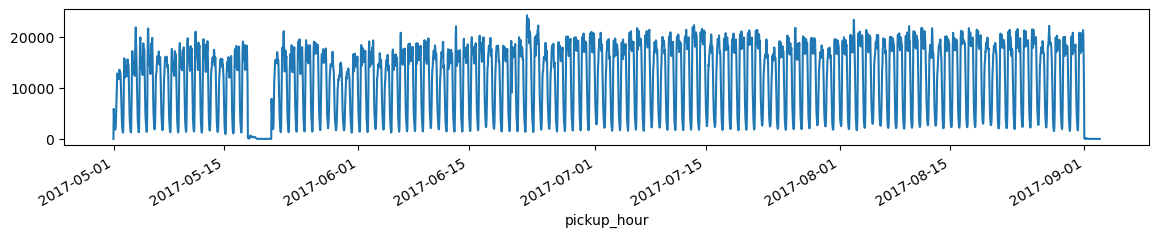

In [5]:
# 统计一个月内每个小时的订单量
fhvhv_data['departure_time'] = pd.to_datetime(fhvhv_data['departure_time'])
fhvhv_data['arrival_time'] = pd.to_datetime(fhvhv_data['arrival_time'])
fhvhv_data['pickup_hour'] = fhvhv_data['departure_time'].dt.floor('60min')
fhvhv_data['dropoff_hour'] = fhvhv_data['arrival_time'].dt.floor('60min')

# 可视化
fig = plt.figure(figsize=(14, 2))
fhvhv_data['pickup_hour'].value_counts().sort_index().plot()
plt.show()

In [6]:
zone_lookup_table.head(10)

,Objectid,geometry,CentroidX,CentroidY
0,0,"POLYGON ((116.2746 39.833, 116.2966 39.833, 11...",116.2856,39.842
1,1,"POLYGON ((116.2746 39.851, 116.2966 39.851, 11...",116.2856,39.860
2,2,"POLYGON ((116.2746 39.869, 116.2966 39.869, 11...",116.2856,39.878
3,3,"POLYGON ((116.2746 39.887, 116.2966 39.887, 11...",116.2856,39.896
4,4,"POLYGON ((116.2746 39.905, 116.2966 39.905, 11...",116.2856,39.914
5,5,"POLYGON ((116.2746 39.923, 116.2966 39.923, 11...",116.2856,39.932
6,6,"POLYGON ((116.2746 39.941, 116.2966 39.941, 11...",116.2856,39.950
7,7,"POLYGON ((116.2746 39.959, 116.2966 39.959, 11...",116.2856,39.968
8,8,"POLYGON ((116.2746 39.977, 116.2966 39.977, 11...",116.2856,39.986
9,9,"POLYGON ((116.2966 39.833, 116.3186 39.833, 11...",116.3076,39.842


In [7]:
all_place = fhvhv_data['start_grid_id'].value_counts()
all_place = all_place.index.tolist()
print(len(all_place))

90


In [8]:
# 统计起点地区、终点地区订单数
num_order_origin = fhvhv_data['start_grid_id'].value_counts()
num_order_origin.sort_values(ascending=True, inplace=True)
num_order_origin

start_grid_id
81      36968
8       71235
87      92155
19     127308
10     152965
       ...   
57     771715
75    1018253
67    1145326
76    1225259
68    1337631
Name: count, Length: 90, dtype: int64

In [9]:
num_order_dest = fhvhv_data['end_grid_id'].value_counts()
num_order_dest.sort_values(ascending=True, inplace=True)
num_order_dest

end_grid_id
81      37855
8       59022
87      84190
19     128894
18     149285
       ...   
57     904616
75     987847
67    1065358
76    1079425
68    1448921
Name: count, Length: 90, dtype: int64

In [10]:
cond_o = num_order_origin[num_order_origin>=0]
cond_d = num_order_dest[num_order_dest>=0]
cond_o, cond_d = cond_o.index.to_list(), cond_d.index.tolist()
keep_place = [place_id for place_id in all_place if ((place_id in cond_o) and (place_id in cond_d))]
# keep_place = all_place
print(keep_place)

[68, 76, 67, 75, 57, 58, 78, 31, 77, 59, 66, 37, 69, 74, 49, 17, 55, 70, 85, 32, 30, 21, 50, 16, 33, 40, 62, 84, 26, 12, 25, 15, 65, 80, 73, 60, 20, 29, 89, 36, 23, 88, 64, 38, 52, 46, 43, 48, 39, 42, 54, 61, 11, 4, 44, 34, 22, 14, 51, 28, 24, 6, 47, 53, 86, 41, 56, 35, 1, 7, 5, 13, 27, 82, 2, 45, 72, 63, 9, 79, 83, 3, 0, 71, 18, 10, 19, 87, 8, 81]


In [11]:
keep_place = [place_id for place_id in keep_place]
print('length of keep_place',len(keep_place))
od_list = [f'{i}->{j}' for i in keep_place for j in keep_place]

columns = od_list


length of keep_place 90


In [12]:
zone_lookup_table.head()

,Objectid,geometry,CentroidX,CentroidY
0,0,"POLYGON ((116.2746 39.833, 116.2966 39.833, 11...",116.2856,39.842
1,1,"POLYGON ((116.2746 39.851, 116.2966 39.851, 11...",116.2856,39.860
2,2,"POLYGON ((116.2746 39.869, 116.2966 39.869, 11...",116.2856,39.878
3,3,"POLYGON ((116.2746 39.887, 116.2966 39.887, 11...",116.2856,39.896
4,4,"POLYGON ((116.2746 39.905, 116.2966 39.905, 11...",116.2856,39.914


In [13]:
cols = ['O_x', 'O_y', 'D_x', 'D_y', 'O_Zone', 'D_Zone',	'O_Objectid', 'D_Objectid']

meta_data_Beijing = pd.DataFrame(columns=cols)

meta_data_Beijing['O_Objectid'] = [int(i.split('->')[0]) for i in od_list]
meta_data_Beijing['D_Objectid'] = [int(i.split('->')[1]) for i in od_list]
meta_data_Beijing['O_x'] =    [zone_lookup_table[zone_lookup_table['Objectid'] == i]['CentroidX'].values[0] for i in meta_data_Beijing['O_Objectid']]
meta_data_Beijing['O_y'] =    [zone_lookup_table[zone_lookup_table['Objectid'] == i]['CentroidY'].values[0] for i in meta_data_Beijing['O_Objectid']]
meta_data_Beijing['D_x'] =    [zone_lookup_table[zone_lookup_table['Objectid'] == i]['CentroidX'].values[0] for i in meta_data_Beijing['D_Objectid']]
meta_data_Beijing['D_y'] =    [zone_lookup_table[zone_lookup_table['Objectid'] == i]['CentroidY'].values[0] for i in meta_data_Beijing['D_Objectid']]
meta_data_Beijing['O_Zone'] = [zone_lookup_table[zone_lookup_table['Objectid'] == i]['geometry'].values[0] for i in meta_data_Beijing['O_Objectid']]
meta_data_Beijing['D_Zone'] = [zone_lookup_table[zone_lookup_table['Objectid'] == i]['geometry'].values[0] for i in meta_data_Beijing['D_Objectid']]
meta_data_Beijing.to_csv('GIS/meta_data_Beijing.csv')
meta_data_Beijing.head()


,O_x,O_y,D_x,D_y,O_Zone,D_Zone,O_Objectid,D_Objectid
0,116.4396,39.932,116.4396,39.932,"POLYGON ((116.4286 39.923, 116.4506 39.923, 11...","POLYGON ((116.4286 39.923, 116.4506 39.923, 11...",68,68
1,116.4396,39.932,116.4616,39.914,"POLYGON ((116.4286 39.923, 116.4506 39.923, 11...","POLYGON ((116.4506 39.905, 116.4726 39.905, 11...",68,76
2,116.4396,39.932,116.4396,39.914,"POLYGON ((116.4286 39.923, 116.4506 39.923, 11...","POLYGON ((116.4286 39.905, 116.4506 39.905, 11...",68,67
3,116.4396,39.932,116.4616,39.896,"POLYGON ((116.4286 39.923, 116.4506 39.923, 11...","POLYGON ((116.4506 39.887, 116.4726 39.887, 11...",68,75
4,116.4396,39.932,116.4176,39.896,"POLYGON ((116.4286 39.923, 116.4506 39.923, 11...","POLYGON ((116.4066 39.887, 116.4286 39.887, 11...",68,57


In [14]:
TIME_FREQ = '10min'

time_range = pd.date_range(start='2017-06-01', end='2017-08-31 23:59:59', freq=TIME_FREQ)
# 创建空表格, 初始化列和索引
df = pd.DataFrame(columns=columns)
df['time'] = time_range
df.set_index('time', inplace=True)
df_TTE = df.copy().fillna(1e6+0.1)


C:\Users\Administrator\AppData\Local\Temp\ipykernel_4516\2190254538.py:8: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_TTE = df.copy().fillna(1e6+0.1)


In [15]:
fhvhv_data.head()

,departure_time,arrival_time,start_grid_id,end_grid_id,pickup_hour,dropoff_hour
0,2017-05-07 11:37:17,2017-05-07 11:57:30,33,68,2017-05-07 11:00:00,2017-05-07 11:00:00
1,2017-05-07 11:37:17,2017-05-07 11:52:44,15,15,2017-05-07 11:00:00,2017-05-07 11:00:00
2,2017-05-07 11:41:23,2017-05-07 12:03:17,12,0,2017-05-07 11:00:00,2017-05-07 12:00:00
3,2017-05-07 11:41:27,2017-05-07 12:11:52,65,12,2017-05-07 11:00:00,2017-05-07 12:00:00
4,2017-05-07 11:37:42,2017-05-07 12:02:37,60,68,2017-05-07 11:00:00,2017-05-07 12:00:00


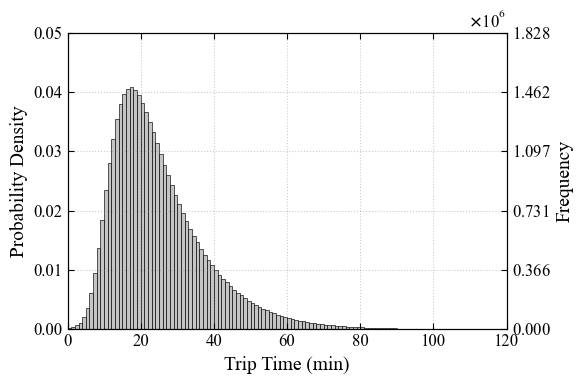

Mean Trip Time: 25.34 min
1st-99th Percentile: 6.27 min - 70.40 min
99.9th Percentile: 103.80 min


In [16]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.ticker as ticker

fhvhv_data['trip_time'] = (fhvhv_data['arrival_time'] - fhvhv_data['departure_time']).dt.total_seconds() / 60.0
travel_time = fhvhv_data['trip_time'].values

# 全局字体设置 (推荐 Times New Roman 用于学术图表)
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['font.size'] = 12

# 创建画布
fig, ax1 = plt.subplots(figsize=(6, 4)) # 增加高度以适应双轴标签

# 参数设置
bins_num = 120
range_lim = (0, 120)
bin_width = (range_lim[1] - range_lim[0]) / bins_num

# ==========================================
# 2. 绘制主图 (左轴：密度)
# ==========================================
# 使用灰度配色：facecolor为浅灰，edgecolor为黑色，增强边界清晰度
counts, bins, patches = ax1.hist(
    travel_time, 
    bins=bins_num, 
    range=range_lim, 
    density=True, 
    color='#bfbfbf',       # 灰色填充
    edgecolor='black',     # 黑色边框
    linewidth=0.5,         # 边框线宽
    alpha=0.9              # 透明度
)

# 左轴标签与刻度设置
ax1.set_xlabel('Trip Time (min)', fontsize=14)
ax1.set_ylabel('Probability Density', fontsize=14)
ax1.set_xlim(range_lim)
ax1.set_ylim(0, 0.05) # 留出10%空间避免顶格
# 刻度朝内，显得更紧凑专业
ax1.tick_params(direction='in', top=True, right=False, length=4) 

# ==========================================
# 3. 设置副轴 (右轴：数量/频数)
# ==========================================
ax2 = ax1.twinx()

# 核心逻辑：数学换算确保左右轴严格对齐
# Density = Count / (N * Bin_Width)  ==>  Count = Density * N * Bin_Width
N = len(travel_time)
density_ylim = ax1.get_ylim() # 获取左轴当前的显示范围
count_max = density_ylim[1] * N * bin_width # 计算对应的右轴最大值

ax2.set_ylim(0, count_max)
ax2.set_yticks(np.linspace(0, count_max, 6)) # 设置5个刻度
ax2.set_ylabel('Frequency', fontsize=14)

# 科学计数法设置
formatter = ticker.ScalarFormatter(useMathText=True)
formatter.set_powerlimits((-2, 3)) # 强制使用 10^x 显示
ax2.yaxis.set_major_formatter(formatter)
ax2.tick_params(direction='in', left=False, length=4)

# ==========================================
# 4. 辅助元素优化
# ==========================================
# 标题 (注：很多期刊要求标题写在图注Caption中，图内不写标题。若需要图内标题，可保留下行)
# plt.title('DiDi Beijing', fontsize=16, pad=15)

# 添加微弱网格线辅助读数
ax1.grid(True, linestyle=':', alpha=0.4, color='gray')

plt.tight_layout()
# 保存为pdf
plt.savefig('Beijing_TripTime_Distribution.pdf', format='pdf', dpi=600)
plt.show()

# ==========================================
# 5. 统计输出 (保持原有逻辑)
# ==========================================
print(f'Mean Trip Time: {travel_time.mean():.2f} min')
p1, p99, p999 = np.percentile(travel_time, [1, 99, 99.9])
print(f'1st-99th Percentile: {p1:.2f} min - {p99:.2f} min')
print(f'99.9th Percentile: {p999:.2f} min')

In [17]:
file_list = ['Beijing/all_data_in_grid.parquet']
results = []
for file in file_list:
    print(f"Processing {file}...")
    # Read and preprocess data
    # 只保留6月到8月的数据
    fhvhv_data = pd.read_parquet(file)
    
    # Convert to datetime and floor
    fhvhv_data['departure_time'] = pd.to_datetime(fhvhv_data['departure_time'])
    fhvhv_data['arrival_time'] = pd.to_datetime(fhvhv_data['arrival_time'])
    fhvhv_data = fhvhv_data[(fhvhv_data['departure_time'].dt.month >= 6) & (fhvhv_data['departure_time'].dt.month <= 8)]
    fhvhv_data['trip_time'] = (fhvhv_data['arrival_time'] - fhvhv_data['departure_time']).dt.total_seconds() / 60.
    fhvhv_data['departure_time'] = fhvhv_data['departure_time'].dt.floor(TIME_FREQ)

    fhvhv_data = fhvhv_data[fhvhv_data['trip_time'] <= 80]
    fhvhv_data = fhvhv_data[fhvhv_data['trip_time'] >= 3]
    
    # Filter rows
    fhvhv_data['start_grid_id'] = fhvhv_data['start_grid_id'].astype(int)
    fhvhv_data['end_grid_id'] = fhvhv_data['end_grid_id'].astype(int)

    fhvhv_data = fhvhv_data[
        fhvhv_data['start_grid_id'].isin(keep_place) & 
        fhvhv_data['end_grid_id'].isin(keep_place)
    ]

    # 只保留需要的列
    fhvhv_data = fhvhv_data[['departure_time', 'start_grid_id', 'end_grid_id', 'trip_time']]
    print('keeped fhvhv_data shape:', fhvhv_data.shape)

    if not fhvhv_data.empty:
        # Group by pickup time and OD pair, taking the minimum trip time
        grouped = fhvhv_data.groupby(['departure_time', 'start_grid_id', 'end_grid_id'])['trip_time'].median().reset_index()
        results.append(grouped)

# Combine results
if results:
    all_data = pd.concat(results, ignore_index=True)
    
    # Global groupby to get min across all files
    final_grouped = all_data.groupby(['departure_time', 'start_grid_id', 'end_grid_id'])['trip_time'].median().reset_index()
    
    # Create OD string column
    final_grouped['OD'] = final_grouped['start_grid_id'].astype(str) + '->' + final_grouped['end_grid_id'].astype(str)
    
    # Pivot to wide format
    df_pivot = final_grouped.pivot(index='departure_time', columns='OD', values='trip_time')
    
    # Reindex to match the desired time range and OD columns
    df_TTE = df_pivot.reindex(index=time_range, columns=columns)
    
    print("Done!")
else:
    print("No data processed.")

df_TTE.to_parquet('Beijing/Processed/TTE_raw.parquet')

Processing Beijing/all_data_in_grid.parquet...
keeped fhvhv_data shape: (28680412, 4)
Done!


In [18]:
# 检查每个OD的NaN率
df_TTE = pd.read_parquet('Beijing/Processed/TTE_raw.parquet')
df_TTE.head(5)

OD,68->68,68->76,68->67,68->75,68->57,68->58,68->78,68->31,68->77,68->59,...,81->83,81->3,81->0,81->71,81->18,81->10,81->19,81->87,81->8,81->81
2017-06-01 00:00:00,14.200000,19.808333,12.666667,15.483333,18.583333,14.383333,11.950000,38.866667,13.783333,13.983333,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-06-01 00:10:00,16.366667,23.491667,14.166667,22.525000,24.650000,7.483333,9.325000,21.416667,NaN,16.083333,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-06-01 00:20:00,9.891667,18.366667,19.950000,17.766667,NaN,19.008333,14.391667,NaN,14.916667,28.466667,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-06-01 00:30:00,8.925000,12.683333,15.241667,13.816667,18.683333,12.400000,14.816667,NaN,16.766667,9.716667,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.766667
2017-06-01 00:40:00,10.016667,15.033333,11.450000,13.500000,22.266667,20.616667,18.991667,NaN,17.500000,13.333333,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [19]:
from functions_dp import *

config = DEFAULT_CONFIG

pruner = SpatialPruner(meta_data_Beijing)


SpatialPruner 初始化完成: 共有 90 个 Grid/Zone。


In [24]:
fhvhv_data.head()

,departure_time,start_grid_id,end_grid_id,trip_time
4927846,2017-06-01 05:50:00,67,37,22.500000
4927982,2017-06-01 08:20:00,84,79,44.116667
4928228,2017-06-01 08:30:00,52,39,44.200000
4928428,2017-06-01 00:00:00,68,33,21.183333
4928433,2017-06-01 05:50:00,0,37,25.783333


In [20]:

df_final = run_imputation_pipeline(df_TTE, pruner, config=config)
# df_final = run_imputation_pipeline(df_final, pruner, config=config)
df_final.to_parquet('Beijing/Processed/TTE_imputed_with_DP.parquet')


开始处理 8100 个 OD 对...


100%|██████████| 8100/8100 [03:12<00:00, 42.19it/s]


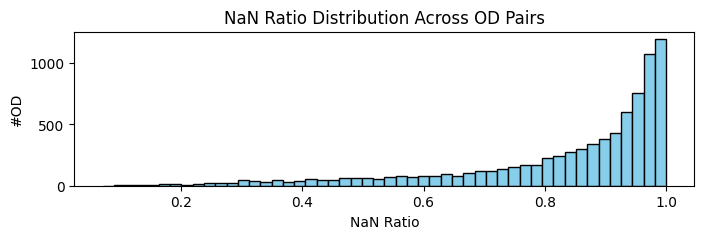

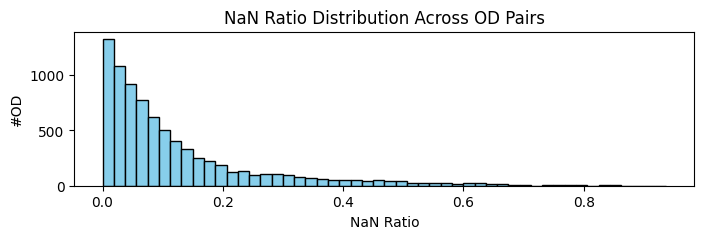

In [21]:
# 绘制NaN率分布图，左侧纵轴为OD对数量，横轴为NaN率
missing_ratio_dict = {col: df_TTE[col].isna().mean() for col in df_TTE.columns}
ratios = list(missing_ratio_dict.values())
fig, ax = plt.subplots(figsize=(8, 2))
ax.hist(ratios, bins=50, color='skyblue', edgecolor='black')
ax.set_xlabel('NaN Ratio')
ax.set_ylabel('#OD')
ax.set_title('NaN Ratio Distribution Across OD Pairs')
plt.show()


missing_ratio_dict = {col: df_final[col].isna().mean() for col in df_final.columns}
ratios = list(missing_ratio_dict.values())
fig, ax = plt.subplots(figsize=(8, 2))
ax.hist(ratios, bins=50, color='skyblue', edgecolor='black')
ax.set_xlabel('NaN Ratio')
ax.set_ylabel('#OD')
ax.set_title('NaN Ratio Distribution Across OD Pairs')
plt.show()

In [22]:
max(ratios)

np.float64(0.9371225845410628)